# **Privacy Attacks and Differential Privacy Mitigation**

This notebook implements and evaluates:
- **Client Identification Attack:** Random Forest classifier trained on model update statistics to predict each client identity, followed by an interpretability analysis via SHAP;

- **Property Inference Attack:**  Random Forest regression on the same features to predict local dataset size and cell-type composition, in order to reconstruct each client profile;

- **Differential Privacy:** untargeted and targeted noise injection, considering increasing levels of noise.

See the accompanying report for theoretical background, methodology description and result discussion.

In [1]:
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shap
import anndata
import scvi
import sys
import json
import anndata as ad

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestRegressor

from scipy.spatial.distance import cosine

/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Client Identification Attack**

This section trains a Random Forest classifier that, given only the model update sent by a client to the server during federated training, attempts to identify which institution produced it. From each stored update, we extract a set of statistical features for every weight tensor in the model (mean, standard deviation, L2 norm, minimum and maximum value) and use these features to train the classifier on a subset of rounds. The classifier is then evaluated on unseen rounds, simulating a realistic attacker who observes the training process and must generalize to future communication rounds. The following cells cover classifier training, evaluation through classification report and confusion matrix and an interpretability analysis via SHAP, to understand which components of the model are most informative for the attack. We then repeat the same attack restricted to only the three weight tensors identified by SHAP as most influential, to test whether an adversary needs access to the full model update at all. Finally, we investigate two possible explanations for the observed per-client performance differences: the correlation between per-client F1-score and local dataset size and the correlation between cell-type composition similarity and the number of classification errors between client pairs.

In [2]:
# Helper functions

def parse_filename(path):
    """
    Extract the round number and client ID from a file path using regex.
    Expected filename format: 'round{R}_client{C}.npz'
    
    Args:
        path (str): Filepath to parse.
        
    Returns:
        tuple[int, int]: A tuple containing (round_id, client_id).
    """
    m = re.search(r"round(\d+)_client(\d+)\.npz", path)
    return int(m.group(1)), int(m.group(2))


def featurize(weights_list):
    """
    Extract statistical summary features from a list of layer weights.

    Args:
        weights_list (list of np.ndarray): List of weight matrices/tensors for each layer.

    Returns:
        np.ndarray: 1D array of concatenated summary features (5 metrics per layer).
    """
    feats = []
    for layer in weights_list:
        # Flatten multi-dimensional weight matrix into a 1D vector
        flat = layer.flatten()
        # Compute summary metrics to capture layer distribution properties
        feats.extend([
            flat.mean(),                    # Average weight magnitude
            flat.std(),                     # Standard deviation
            np.linalg.norm(flat),           # L2 norm
            flat.min(),                     # Minimum weight value
            flat.max(),                     # Maximum weight value
        ])
    return np.array(feats)


def featurize_subset(weights_list, layer_indices):
    """
    Extract summary statistical features exclusively from a designated subset of layers.

    Args:
        weights_list (list of np.ndarray): List of all layer weights for a client update.
        layer_indices (list of int): Indices of the specific layers to include.

    Returns:
        np.ndarray: 1D array of concatenated summary features for the chosen layers.
    """
    feats = []
    for i in layer_indices:
        layer = weights_list[i]
        flat = layer.flatten()
        # Extract summary statistics (mean, std, norm, min, max) for one layer only
        feats.extend([
            flat.mean(), flat.std(), np.linalg.norm(flat),
            flat.min(), flat.max(),
        ])
    return np.array(feats)

In [3]:
# Directory path containing saved client update files (.npz) from federated training
UPDATES_DIR = "../client_updates"

files = sorted(glob.glob(f"{UPDATES_DIR}/round*_client*.npz"))
print(f"Found {len(files)} files")

records = []
for f in files:
    # Extract metadata encoded in the filename
    round_id, client_id = parse_filename(f)
    npz = np.load(f)
    # Identify keys
    layer_keys = [k for k in npz.files if k != "num_examples"]
    # Extract weight matrices for each layer
    weights = [npz[k] for k in layer_keys]
    # Extract sample count if available in the archive, default to None
    num_examples = int(npz["num_examples"]) if "num_examples" in npz.files else None
    # Store structured client update record
    records.append({
        "round": round_id,
        "client_id": client_id,
        "weights": weights,
        "num_examples": num_examples,
    })

# Extract unique sorted lists of processed rounds and client IDs for verification
rounds_available = sorted(set(r["round"] for r in records))
clients_available = sorted(set(r["client_id"] for r in records))
print("Available rounds:", rounds_available)
print("Available clients:", clients_available)

Found 455 files
Available rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
Available clients: [0, 1, 2, 3, 4, 5, 6]


In [4]:
# Feature engineering: transform layer weight arrays into a single feature vector
# We extract aggregated layer-wise summary statistics (mean, std, norm, min, max) as a dimensionality reduction trade-off,
# since using model weights directly can result in an extremely large flattened vector

# Build the dataset matrices:
# X_all: feature matrix (shape: [n_samples, n_features_per_client])
# y_all: target labels (client IDs)
# round_all: array tracking the federated round associated with each sample
X_all = np.stack([featurize(r["weights"]) for r in records])
y_all = np.array([r["client_id"] for r in records])
round_all = np.array([r["round"] for r in records])

print("X shape:", X_all.shape)

X shape: (455, 125)


In [6]:
# Train/Test split by round, not by client
# Splitting by round prevents data leakage: we want to verify that the classifier generalizes to unseen rounds,
# rather than simply memorizing updates from the same round/client seen during training

# Keep the last 30% of available rounds for testing, ensuring at least 1 round
n_test_rounds = max(1, int(0.3 * len(rounds_available)))
# Temporal split: Use the latest rounds for evaluation, earlier rounds for training
test_rounds = set(rounds_available[-n_test_rounds:]) 
train_rounds = set(rounds_available) - test_rounds

# Create boolean masks to slice feature matrices based on round membership
train_mask = np.array([r in train_rounds for r in round_all])
test_mask = ~train_mask

# Divide features (X) and target client labels (y) into train and test sets
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Training set dimension: {X_train.shape[0]} (round {sorted(train_rounds)})")
print(f"Test set dimension: {X_test.shape[0]} (round {sorted(test_rounds)})")

Training set dimension: 322 (round [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])
Test set dimension: 133 (round [47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65])


In [7]:
# Classifier training and evaluation

# Initialize Random Forest with 200 decision trees for robust classification
clf = RandomForestClassifier(n_estimators = 200, random_state = 0)

# Fit the classifier
clf.fit(X_train, y_train)

# Predict client identities on unseen test rounds
y_pred = clf.predict(X_test)

# Calculate overall accuracy and compute the theoretical random guessing baseline
acc = accuracy_score(y_test, y_pred)
baseline = 1 / len(clients_available)
print(f"Random Forest Accuracy: {acc:.3f}")
print(f"Random Baseline Accuracy: {baseline:.3f}")

# Per-class precision, recall and F1-score to evaluate per-client performance
report_dict = classification_report(y_test, y_pred, output_dict=True)

Random Forest Accuracy: 0.692
Random Baseline Accuracy: 0.143


Text(0.5, 0.96, 'Client Identification Attack with Random Forest')

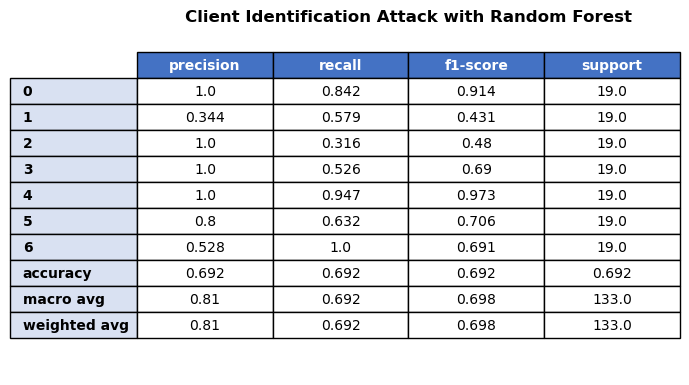

In [8]:
# Classification report (precision, recall, F1-score per client, plus macro/weighted averages)
# as a table image, to be included in the report alongside the confusion matrix

df_report = pd.DataFrame(report_dict).transpose().round(3)
fig, ax = plt.subplots(figsize = (7, len(df_report)*0.4 + 0.5)) 
ax.axis('off')
table = ax.table(
    cellText = df_report.values,
    rowLabels = df_report.index,
    colLabels = df_report.columns,
    cellLoc = 'center',
    loc = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', weight = 'bold')
    elif col == -1:
        cell.set_facecolor('#D9E1F2')
        cell.set_text_props(weight = 'bold')

fig.subplots_adjust(top = 0.85, bottom = 0.05) 
ax.set_title("Client Identification Attack with Random Forest", fontweight = "bold", y = 0.96)

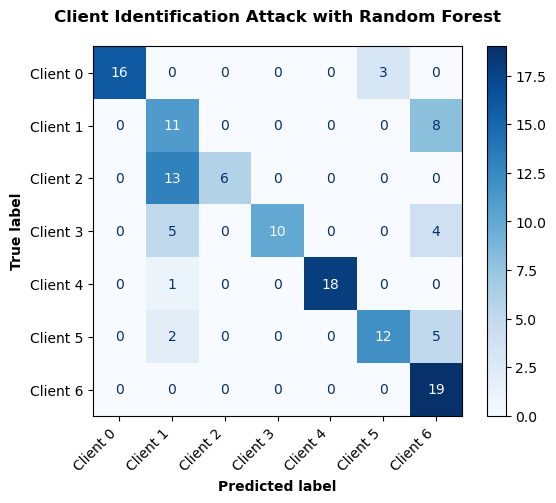

In [9]:
# Display the confusion matrix to visually compare ground truth and predicted client IDs
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[f"Client {i}" for i in sorted(clients_available)],
    cmap='Blues'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Predicted label", fontweight="bold")
plt.ylabel("True label", fontweight="bold")
plt.title("Client Identification Attack with Random Forest", fontweight="bold", pad = 18)
plt.savefig("confusion_matrix_client_id.png", dpi = 150, bbox_inches = 'tight')

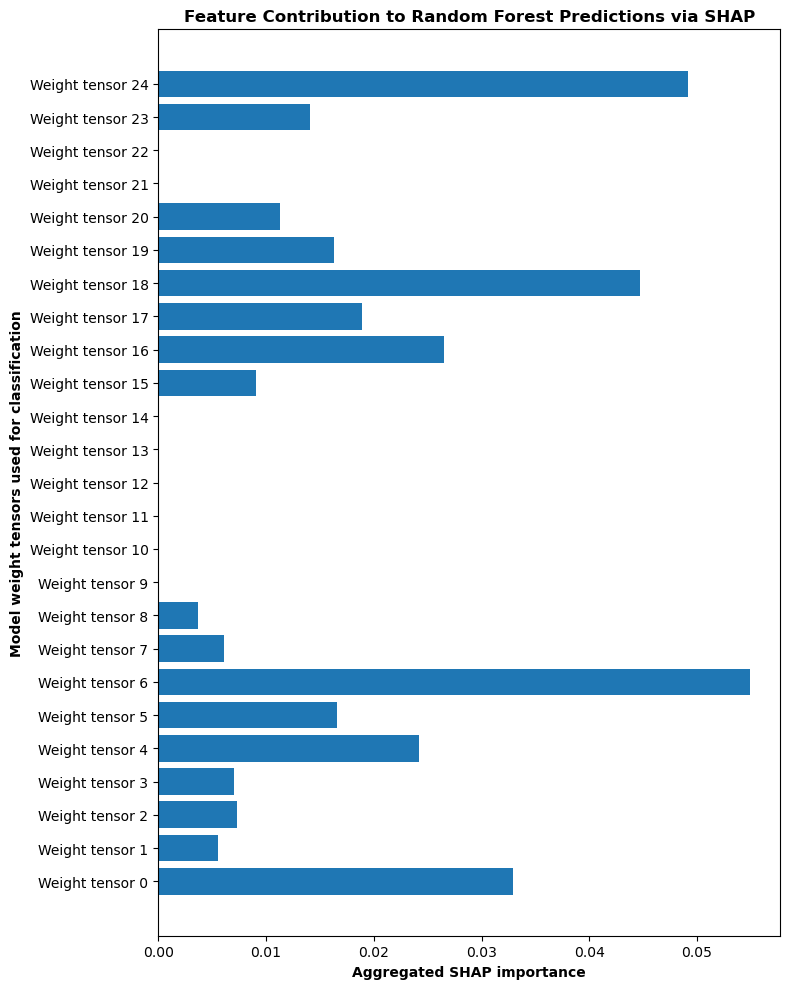

In [10]:
# Layer Importance Analysis: explain Random Forest behaviour via SHAP
# Identifies which layers carry the strongest client identificability capacity.
# Useful for determining where to target noise injection when applying Differential Privacy

# Number of statistical summary features extracted per layer: mean, std, norm, min, max
n_feats_per_layer = 5
# Total layer count
n_layers = X_test.shape[1] // n_feats_per_layer

# Build human-readable feature names
feat_names = []
for i in range(n_layers):
    for stat in ["mean", "std", "norm", "min", "max"]:
        feat_names.append(f"layer{i}_{stat}")

# SHAP: fit a tree explainer on the trained classifier and compute SHAP values for the test set
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Global importance per feature: average the absolute SHAP value of each feature across all test samples
mean_abs_shap = np.abs(shap_values).mean(axis = 0)  

# If shap_values has a class dimension (multiclass), average across classes as well
if mean_abs_shap.ndim > 1:
    mean_abs_shap = mean_abs_shap.mean(axis=1)

# Reshape feature importances to (n_layers, 5) and sum contributions of feature types
# to compute the aggregate importance weight for each individual layer
layer_shap_importance = mean_abs_shap.reshape(n_layers, n_feats_per_layer).sum(axis = 1)

# Plot aggregated SHAP importance per layer as a horizontal bar chart
plt.figure(figsize=(8,10))
plt.barh(range(n_layers), layer_shap_importance)
plt.yticks(range(n_layers), [f"Weight tensor {i}" for i in range(n_layers)])
plt.xlabel("Aggregated SHAP importance", fontweight = "bold")
plt.ylabel("Model weight tensors used for classification", fontweight = "bold")
plt.title("Feature Contribution to Random Forest Predictions via SHAP", fontweight = "bold")
plt.tight_layout()

In [11]:
# Reconstruct the scVI model architecture used during federated training, to map the numeric weight tensor
# of the SHAP analysis to their real names, in order to interpret which model components are most informative for the attack

sys.path.append("../exercise-scvi")
from app.task import get_architecture

# Load a sample client's local training data, just to build the AnnData object needed by scVI's setup
adata = anndata.read_h5ad("../data_federated/data_client_0/train.h5ad")
# Load data used during training. Any client's file is equally valid here, as all clients share the same top-2000 HVG list
# which was computed globally. The server combines statistics from all clients and redistributes a common gene list to each participant 
with open("../data_federated/data_client_0/top2k_genes.json") as f:
    hvg_list = json.load(f)

adata = adata[:, hvg_list].copy()

# Register the technology field, consistent with the federated training setup
adata.obs["tech"] = pd.Categorical(adata.obs["tech"].astype(str))
scvi.model.SCVI.setup_anndata(adata, batch_key="tech", layer="counts")

# Reconstruct the exact same architecture used during federated training,
# instead of scVI's library defaults
arch_cfg = get_architecture({})

scvi_model = scvi.model.SCVI(adata, **arch_cfg)

# Print the index and name of every parameter tensor in the model,
# in the same order used to index weight tensors in the SHAP plot above
for i, (name, param) in enumerate(scvi_model.module.state_dict().items()):
    print(i, name)

2026-08-19 11:06:29,058	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


0 px_r
1 z_encoder.encoder.fc_layers.Layer 0.0.weight
2 z_encoder.encoder.fc_layers.Layer 0.0.bias
3 z_encoder.encoder.fc_layers.Layer 1.0.weight
4 z_encoder.encoder.fc_layers.Layer 1.0.bias
5 z_encoder.mean_encoder.weight
6 z_encoder.mean_encoder.bias
7 z_encoder.var_encoder.weight
8 z_encoder.var_encoder.bias
9 l_encoder.encoder.fc_layers.Layer 0.0.weight
10 l_encoder.encoder.fc_layers.Layer 0.0.bias
11 l_encoder.mean_encoder.weight
12 l_encoder.mean_encoder.bias
13 l_encoder.var_encoder.weight
14 l_encoder.var_encoder.bias
15 decoder.px_decoder.fc_layers.Layer 0.0.weight
16 decoder.px_decoder.fc_layers.Layer 0.0.bias
17 decoder.px_decoder.fc_layers.Layer 1.0.weight
18 decoder.px_decoder.fc_layers.Layer 1.0.bias
19 decoder.px_scale_decoder.0.weight
20 decoder.px_scale_decoder.0.bias
21 decoder.px_r_decoder.weight
22 decoder.px_r_decoder.bias
23 decoder.px_dropout_decoder.weight
24 decoder.px_dropout_decoder.bias


/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Pearson correlation coefficient between local dataset size and F1-score: 0.524


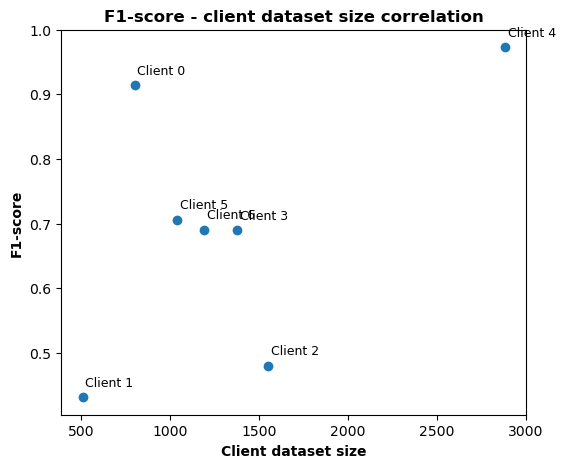

In [12]:
# F1-score vs dataset dimension
# Tests whether re-identification risk correlates with local dataset size across clients

# Values from the classification report above
f1_per_client = report_dict  
# Dataset size per client
num_examples_per_client = {cid: np.mean([r["num_examples"] for r in records if r["client_id"]==cid]) for cid in sorted(clients_available)}

# Extract F1-score and dataset size per client
f1_scores = [f1_per_client[str(cid)]['f1-score'] for cid in sorted(clients_available)]
sizes = [num_examples_per_client[cid] for cid in sorted(clients_available)]

plt.figure(figsize = (6,5))
plt.scatter(sizes, f1_scores)
# Offset each label
for i, cid in enumerate(sorted(clients_available)):
    plt.annotate(
        f"Client {cid}",
        (sizes[i], f1_scores[i]),
        textcoords = "offset points",
        xytext=(2, 8),  
        fontsize=9,
    )
plt.xlabel("Client dataset size", fontweight = "bold")
plt.ylabel("F1-score", fontweight = "bold")
plt.title("F1-score - client dataset size correlation", fontweight = "bold")
plt.savefig("f1_vs_size.png", dpi=150, bbox_inches = 'tight')

# Pearson correlation between local dataset size and per-client F1-score
print(f"Pearson correlation coefficient between local dataset size and F1-score: {np.corrcoef(sizes, f1_scores)[0,1]:.3f}")

In [13]:
# Cell-type similarity vs number of errors
# Tests whether clients with similar cell-type composition are more frequently confused with one another by the attacker

# Recompute the confusion matrix with an explicit, sorted client ordering,
# so that indices align correctly with props_df below
ids = sorted(clients_available)
cm = confusion_matrix(y_test, y_pred, labels=ids)

# Load each client's raw training data to compute its true cell-type composition
client_dirs = sorted(glob.glob("../data_federated/data_client_*"))

celltype_props = {}
for client_dir in client_dirs:
    client_id = int(client_dir.rstrip("/").split("_")[-1])
    adata = ad.read_h5ad(f"{client_dir}/train.h5ad")
    # Proportion of each cell type in this client's local dataset
    celltype_props[client_id] = adata.obs["celltype"].value_counts(normalize=True)

# Rows = clients, columns = cell types, values = proportion (0 where a type is absent)
props_df = pd.DataFrame(celltype_props).fillna(0).T

# Build a ranked table of all client pairs: cell-type distance vs total classification errors
pairs = []
for ci in props_df.index:
    for cj in props_df.index:
        if ci < cj:
            # Cosine distance between the two clients' cell-type composition vectors
            d = cosine(props_df.loc[ci], props_df.loc[cj])
            # Sum of confusion-matrix errors in both directions for this client pair
            n_err = cm[ids.index(ci), ids.index(cj)] + cm[ids.index(cj), ids.index(ci)]
            pairs.append((ci, cj, d, n_err))

pairs_df = pd.DataFrame(pairs, columns=["Client_A", "Client_B", "Distance", "Total_errors"])
pairs_df = pairs_df.sort_values("Distance").reset_index(drop=True)
pairs_df["Rank"] = pairs_df.index + 1

print(pairs_df.to_string(index=False))

# Convert distance to similarity (1 = identical composition, 0 = maximally different)
# and correlate it with the number of classification errors for that client pair
pairs_df["Celltype_similarity"] = 1 - pairs_df["Distance"]
corr_sim = np.corrcoef(pairs_df["Celltype_similarity"], pairs_df["Total_errors"])[0, 1]
print(f"Correlation between celltype similarity and total errors: {corr_sim:.3f}")

 Client_A  Client_B  Distance  Total_errors  Rank
        1         6  0.055903             8     1
        3         6  0.074620             4     2
        1         3  0.097229             5     3
        2         5  0.103759             0     4
        1         5  0.107526             2     5
        3         5  0.128868             0     6
        1         2  0.137633            13     7
        1         4  0.144963             1     8
        3         4  0.147926             0     9
        0         4  0.150906             0    10
        4         6  0.178914             0    11
        0         5  0.230312             3    12
        4         5  0.230743             0    13
        5         6  0.243418             5    14
        0         3  0.249951             0    15
        2         4  0.289961             0    16
        2         3  0.318948             0    17
        2         6  0.334303             0    18
        0         1  0.378344             0    19


Text(0.5, 0.96, 'Classification errors and celltype similarity')

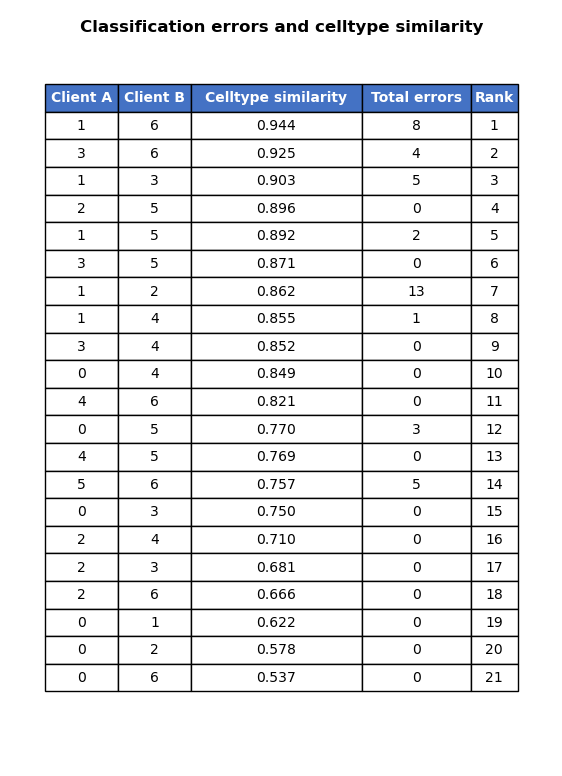

In [14]:
# Visualize the previous output as a table to be inserted in the report

pairs_df["Celltype_similarity"] = 1 - pairs_df["Distance"]
df_report_pairs = pairs_df[["Client_A", "Client_B", "Celltype_similarity", "Total_errors", "Rank"]].copy()
df_report_pairs = df_report_pairs.sort_values("Rank")

# Build a string version of the table, formatting integer columns and the
# similarity column separately
int_cols = ["Client A", "Client B", "Total_errors", "Rank"]
cell_text = []
for _, row in df_report_pairs.iterrows():
    cell_text.append([
        f"{int(row.Client_A)}",
        f"{int(row.Client_B)}",
        f"{row.Celltype_similarity:.3f}",
        f"{int(row.Total_errors)}",
        f"{int(row['Rank'])}",
    ])

fig, ax = plt.subplots(figsize = (7, len(df_report_pairs)*0.4 + 0.5))
ax.axis('off')
table = ax.table(
    cellText = cell_text,
    colLabels = ["Client A", "Client B", "Celltype similarity", "Total errors", "Rank"],
    cellLoc = 'center',
    loc = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

table.auto_set_column_width(col=list(range(len(df_report_pairs.columns))))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color = 'white', weight = 'bold')

fig.subplots_adjust(top = 0.9, bottom = 0.05)
ax.set_title("Classification errors and celltype similarity", fontweight = "bold", y = 0.96)

Accuracy considering only layers [6, 18, 24]: 0.774


Text(0.5, 0.96, 'Client Identification Attack on layers [6, 18, 24]')

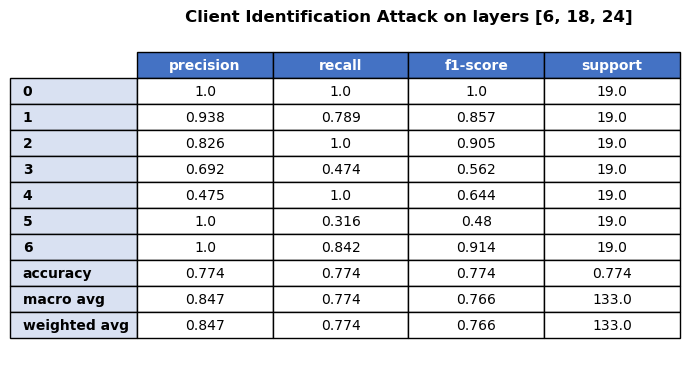

In [15]:
# Client identification attack restricted to the most informative weight tensors identified via SHAP
# Tests whether an adversary needs access to the full model update to succeed

# Define a subset of important layers, identified from the previous layer importance analysis
important_layers = [6, 18, 24]

# Build the reduced feature matrix using only the specified important layers
X_subset = np.stack([featurize_subset(r["weights"], important_layers) for r in records])

# Partition the subset features into training and testing sets using the existing boolean masks
X_train_sub, y_train_sub = X_subset[train_mask], y_all[train_mask]
X_test_sub, y_test_sub = X_subset[test_mask], y_all[test_mask]

# Train a new Random Forest Classifier on the reduced feature space
clf_sub = RandomForestClassifier(n_estimators=200, random_state=0)
clf_sub.fit(X_train_sub, y_train_sub)
# Evaluate model performance on the test set
y_pred_sub = clf_sub.predict(X_test_sub)

# Print the resulting accuracy and classification report
acc_sub = accuracy_score(y_test_sub, y_pred_sub)
print(f"Accuracy considering only layers {important_layers}: {acc_sub:.3f}")

# Build the same styled table used for the full-model classification report
report_dict_sub = classification_report(y_test_sub, y_pred_sub, output_dict=True)
df_report_sub = pd.DataFrame(report_dict_sub).transpose().round(3)

# Table plot
fig, ax = plt.subplots(figsize=(7, len(df_report_sub)*0.4 + 0.5))
ax.axis('off')
table = ax.table(
    cellText = df_report_sub.values,
    rowLabels = df_report_sub.index,
    colLabels = df_report_sub.columns,
    cellLoc = 'center',
    loc = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color = 'white', weight = 'bold')
    elif col == -1:
        cell.set_facecolor('#D9E1F2')
        cell.set_text_props(weight = 'bold')

fig.subplots_adjust(top = 0.85, bottom = 0.05)
ax.set_title(f"Client Identification Attack on layers {important_layers}",
             fontweight="bold", y=0.96)

Text(0.5, 1.0, 'Client identification attack - Important layers')

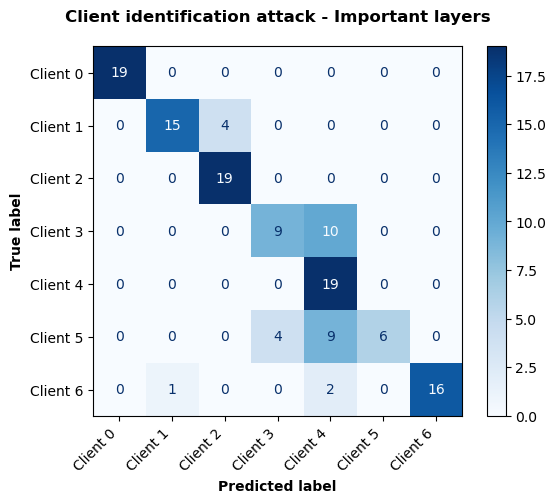

In [16]:
# Display the confusion matrix to visually compare ground truth and predicted client IDs for important layers only
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_sub, y_pred_sub,
    display_labels=[f"Client {i}" for i in sorted(clients_available)],
    cmap='Blues'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Predicted label", fontweight="bold")
plt.ylabel("True label", fontweight="bold")
plt.title("Client identification attack - Important layers", fontweight = "bold", pad = 18)

### **Property Inference Attacks**

Beyond identifying the source client of an update, this section investigates whether statistical properties of a client's local dataset can also be inferred from the same update-derived features, without necessarily identifying the client itself. We try to infer two properties: local dataset size and the composition of cell types in the client's local data. For each property, a Random Forest regressor is trained on the same round-based train/test split used for client identification and evaluated using Mean Absolute Error (MAE) and the coefficient of determination (R²). We first predict dataset size directly, then extend the attack to the four cell types with the highest variance across clients, before combining all inferred attributes into a single reconstructed profile per client.

In [17]:
# Property Inference Attack on dataset size: predicting local dataset size (num_examples) from weight updates
# Evaluates whether an attacker can infer sensitive information directly from client updates

# Extract target array containing local dataset sizes for all client updates
y_size_all = np.array([r["num_examples"] for r in records])

# Partition target sizes into train and test sets using the existing round-based split masks
y_size_train, y_size_test = y_size_all[train_mask], y_size_all[test_mask]

# Random Forest Regressor
reg = RandomForestRegressor(n_estimators=200, random_state=0)
reg.fit(X_train, y_size_train)   

# Predict local dataset sizes on unseen test rounds
y_size_pred = reg.predict(X_test)

# Compute regression performance metrics: Mean Absolute Error (MAE) and Coefficient of Determination (R²)
mae = mean_absolute_error(y_size_test, y_size_pred)
r2 = r2_score(y_size_test, y_size_pred)

# Display evaluation results relative to the average dataset size
print(f"MAE: {mae:.1f} cells")
print(f"R²: {r2:.3f}")
print(f"Dataset mean dimension: {y_size_all.mean():.1f}")

MAE: 314.9 cells
R²: 0.687
Dataset mean dimension: 1337.4


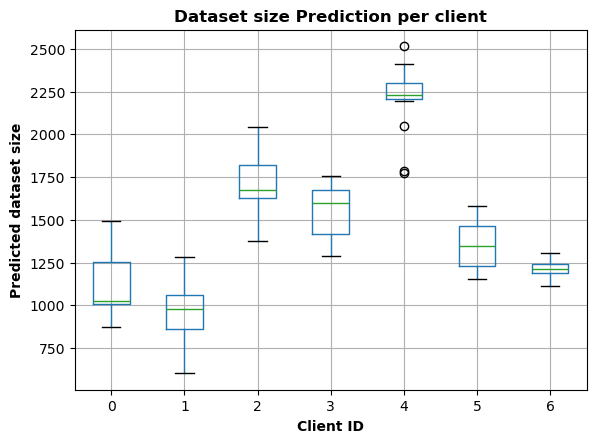

In [18]:
# Create a DataFrame mapping ground-truth client IDs to their predicted dataset sizes for test rounds
df_plot = pd.DataFrame({
    "client_id": y_all[test_mask],
    "predicted_size": y_size_pred
})

df_plot.boxplot(column = "predicted_size", by = "client_id")
plt.suptitle("") 
plt.title("Dataset size Prediction per client", fontweight = "bold")
plt.xlabel("Client ID", fontweight = "bold")
plt.ylabel("Predicted dataset size", fontweight = "bold")
plt.savefig("boxplot_predictions_per_client.png", dpi = 150, bbox_inches = 'tight')

In [19]:
# Property Inference Attack on celltype: predicting the proportion of cell type
# from weight updates, motivated by the earlier finding that cell-type composition
# correlates with how easily the client identification attack confuses clients

# Choose a specific celltype present in props_df
target_celltype = "ductal" 

# Map each update to the true proportion for its client
y_celltype_all = np.array([props_df.loc[r["client_id"], target_celltype] for r in records])

# Partition target values into train/test sets, reusing the existing round-based split masks
y_celltype_train, y_celltype_test = y_celltype_all[train_mask], y_celltype_all[test_mask]

# Train a Random Forest regressor to predict cell-type proportion from update features
reg_celltype = RandomForestRegressor(n_estimators=200, random_state=0)
reg_celltype.fit(X_train, y_celltype_train)

# Predict cell-type proportions on unseen test rounds
y_celltype_pred = reg_celltype.predict(X_test)

# Evaluate regression performance
mae_ct = mean_absolute_error(y_celltype_test, y_celltype_pred)
r2_ct = r2_score(y_celltype_test, y_celltype_pred)
print(f"MAE: {mae_ct:.3f}, R²: {r2_ct:.3f}")

MAE: 0.043, R²: 0.693


In [20]:
# Repeat the property inference attack across the 4 cell types with the highest variance across clients
# (i.e. the most distinctive/informative ones), since near-constant cell types carry little to no signal to infer

top_celltypes = props_df.var(axis = 0).sort_values(ascending = False).head(4).index.tolist()

results = []
for ct in top_celltypes:
    # True proportion of this cell type for each client
    y_ct_all = np.array([props_df.loc[r["client_id"], ct] for r in records])
    y_ct_train, y_ct_test = y_ct_all[train_mask], y_ct_all[test_mask]

    # Train a Random Forest regressor to predict this cell type's proportion
    # from update-derived features (same X_train/X_test as client identification)
    reg_ct = RandomForestRegressor(n_estimators = 200, random_state = 0)
    reg_ct.fit(X_train, y_ct_train)
    y_ct_pred = reg_ct.predict(X_test)

    # Compute the evaluation metrics
    mae = mean_absolute_error(y_ct_test, y_ct_pred)
    r2 = r2_score(y_ct_test, y_ct_pred)
    results.append({"CellType": ct, "MAE": round(mae, 4), "R²": round(r2, 3)})

# Print the metrics per cell-type
results_df = pd.DataFrame(results)
print(results_df)

  CellType     MAE     R²
0    alpha  0.0697  0.547
1   ductal  0.0432  0.693
2     beta  0.0673  0.434
3   acinar  0.0490  0.371


In [21]:
# Aggregate predictions per client (averaged across that client's multiple test-round updates),
# combining client identification, dataset size and cell-type proportion into a single reconstructed profile per institution
summary_rows = []
for cid in sorted(clients_available):
    mask = y_test == cid

    # Most frequently predicted client/technology
    predicted_tech = pd.Series(y_pred[mask]).mode()[0]  
    predicted_size = y_size_pred[mask].mean()
    predicted_celltype = y_celltype_pred[mask].mean()  
    
    true_size = y_size_test[mask].mean()
    true_celltype = props_df.loc[cid, target_celltype]
    
    summary_rows.append({
    "Client": cid,
    "True Tech": int(cid),
    "Predicted Tech": int(predicted_tech),
    "True Size": int(round(true_size)),
    "Predicted Size": int(round(predicted_size)),
    "True CellType Prop": round(true_celltype, 3),
    "Predicted CellType Prop": round(predicted_celltype, 3),
})

summary_df = pd.DataFrame(summary_rows)

Text(0.5, 1.03, 'Reconstructed Client Profile')

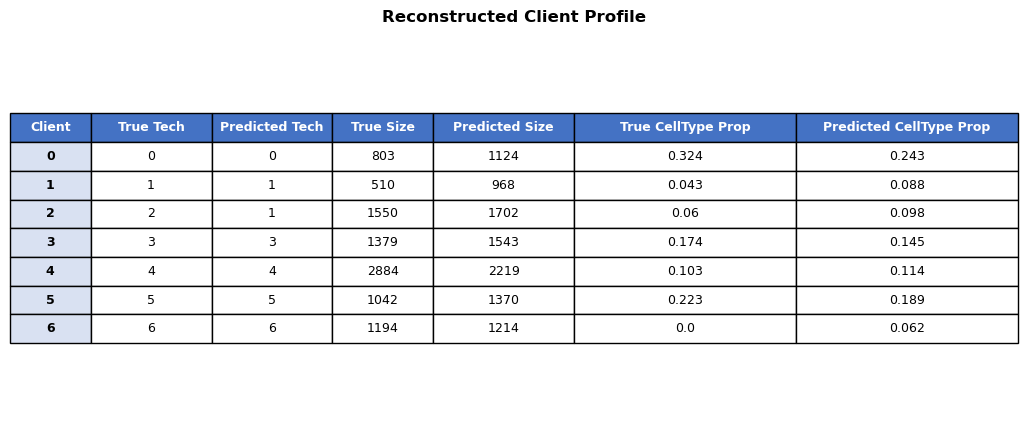

In [22]:
# Reconstruct each client profile as a formatted table image, combining client/technology identification,
# dataset size and cell-type proportion to be included in the report

int_cols = ["Client", "True Tech", "Predicted Tech", "True Size", "Predicted Size"]
float_cols = ["True CellType Prop", "Predicted CellType Prop"]

display_df = summary_df.copy()
for col in int_cols:
    display_df[col] = summary_df[col].round(0).astype(int).astype(str)
for col in float_cols:
    display_df[col] = summary_df[col].round(3).astype(str)

fig, ax = plt.subplots(figsize = (13, len(display_df)*0.5 + 1))
ax.axis('off')
table = ax.table(
    cellText = display_df.values,
    colLabels = display_df.columns,
    cellLoc = 'center',
    loc = 'center',
    colWidths = [0.08, 0.12, 0.12, 0.10, 0.14, 0.22, 0.22]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

header_color = '#4472C4'
row_label_color = '#D9E1F2'

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', weight='bold')
    elif col == 0:
        cell.set_facecolor(row_label_color)
        cell.set_text_props(weight='bold')

fig.subplots_adjust(top = 0.88, bottom = 0.05)
ax.set_title("Reconstructed Client Profile", fontweight = "bold", y = 1.03)

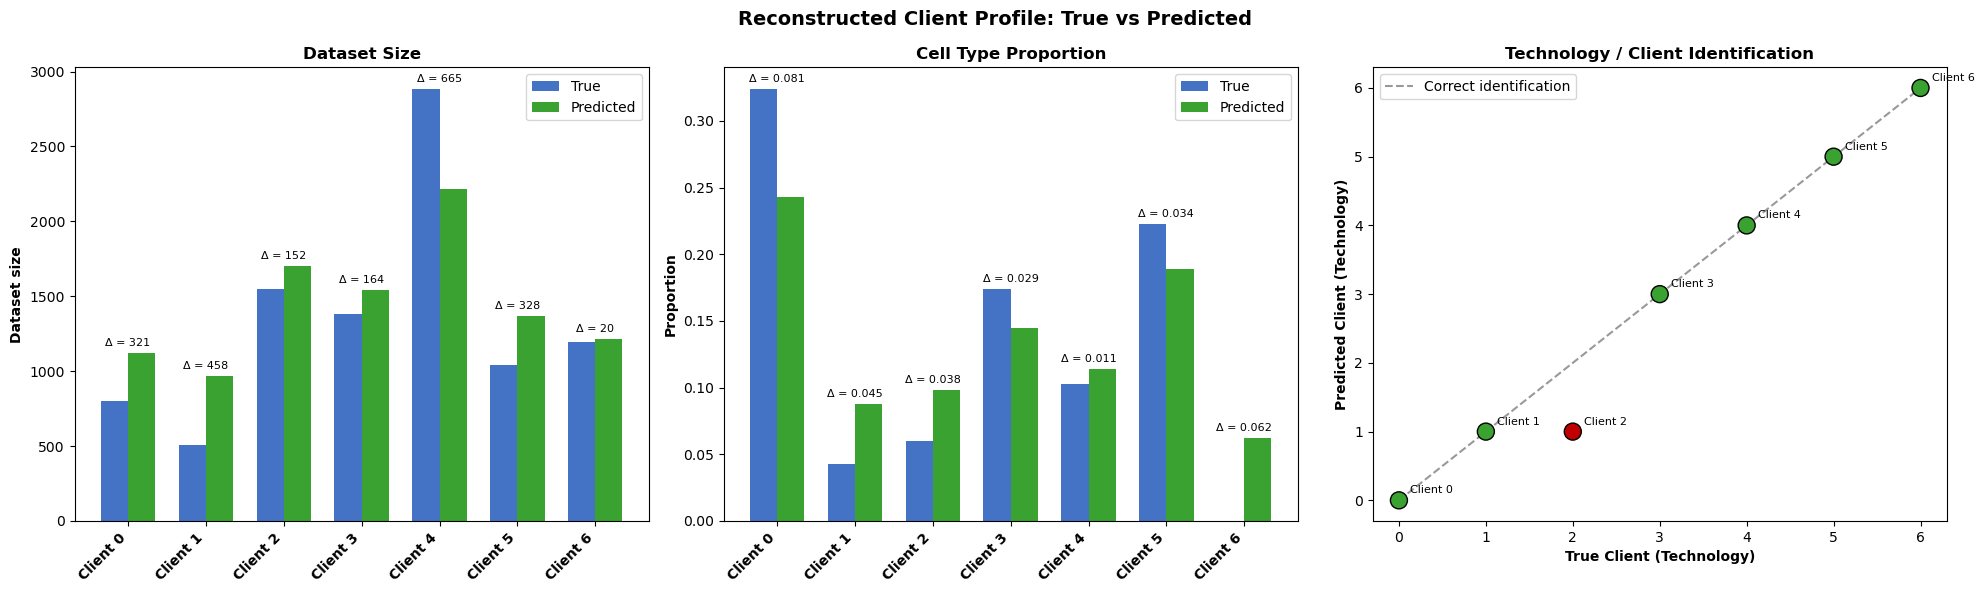

In [23]:
# Combined visual comparison of true vs predicted values across all three attacks
# (dataset size, cell-type proportion, client/technology identity), summarizing the full reconstructed client profile in a single figure

fig, axes = plt.subplots(1, 3, figsize = (20, 6))
x = np.arange(len(summary_df))
width = 0.35
labels = [f"Client {c}" for c in summary_df["Client"]]

# Plot 1: true vs predicted size, with absolute error annotated above each pair of bars
ax = axes[0]
bars_true = ax.bar(x - width/2, summary_df["True Size"], width, label = "True", color = "#4472C4")
bars_pred = ax.bar(x + width/2, summary_df["Predicted Size"], width, label="Predicted", color = "#39A230")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontweight = "bold")
ax.set_ylabel("Dataset size", fontweight = "bold")
ax.set_title("Dataset Size", fontweight="bold")
ax.legend()

for i, (t, p) in enumerate(zip(summary_df["True Size"], summary_df["Predicted Size"])):
    diff = np.abs(p - t)
    y_max = max(t, p)
    ax.annotate(f"Δ = {diff:.0f}", (x[i], y_max), textcoords = "offset points", xytext = (0, 5),
                ha = "center", fontsize = 8, color = "black")

# Plot 2: true vs predicted cell-type proportion, with absolute error annotated
ax = axes[1]
ax.bar(x - width/2, summary_df["True CellType Prop"], width, label="True", color = "#4472C4")
ax.bar(x + width/2, summary_df["Predicted CellType Prop"], width, label = "Predicted", color ="#39A230")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontweight = "bold")
ax.set_ylabel("Proportion", fontweight = "bold")
ax.set_title("Cell Type Proportion", fontweight="bold")
ax.legend()

for i, (t, p) in enumerate(zip(summary_df["True CellType Prop"], summary_df["Predicted CellType Prop"])):
    diff = np.abs(p - t)
    y_max = max(t, p)
    ax.annotate(f"Δ = {diff:.3f}", (x[i], y_max), textcoords = "offset points", xytext = (0, 5),
                ha = "center", fontsize = 8, color = "black")

# Plot 3: technology (client) identification: true vs predicted scatter plot,
# colored by whether the prediction matches the true client (green) or not (red)
ax = axes[2]
true_vals = summary_df["True Tech"]
pred_vals = summary_df["Predicted Tech"]

colors = ["#39A230" if t == p else "#C00000" for t, p in zip(true_vals, pred_vals)]

ax.scatter(true_vals, pred_vals, s = 150, c = colors, edgecolors = "black", zorder = 3)
ax.plot([true_vals.min(), true_vals.max()], [true_vals.min(), true_vals.max()],
        'k--', alpha = 0.4, label = "Correct identification", zorder = 1)

for t, p in zip(true_vals, pred_vals):
    ax.annotate(f"Client {t}", (t, p), textcoords = "offset points", xytext = (8,5), fontsize = 8)

ax.set_xlabel("True Client (Technology)", fontweight = "bold")
ax.set_ylabel("Predicted Client (Technology)", fontweight = "bold")
ax.set_title("Technology / Client Identification", fontweight = "bold")
ax.set_xticks(sorted(true_vals.unique()))
ax.set_yticks(sorted(true_vals.unique()))
ax.legend()

fig.suptitle("Reconstructed Client Profile: True vs Predicted", fontweight = "bold", fontsize = 14)
plt.tight_layout()

### **Differential Privacy**

This section evaluates whether Local Differential Privacy can mitigate the client identification attack demonstrated above and how this impacts model utility. Noise injection and gradient clipping are applied client-side, before updates are transmitted to the server, and are compared across two strategies: an untargeted configuration, where noise is applied uniformly across all model parameters, and a targeted configuration, where noise is restricted to the three weight tensors identified as most informative in the SHAP analysis above, so that only the most relevant information is perturbated. For each strategy, we repeat the client identification attack on updates collected under increasing noise levels, reporting both attack accuracy and the model's final validation loss, to characterize the resulting privacy-utility trade-off. Results for each configuration are stored in the corresponding accuracy and val_loss lists.

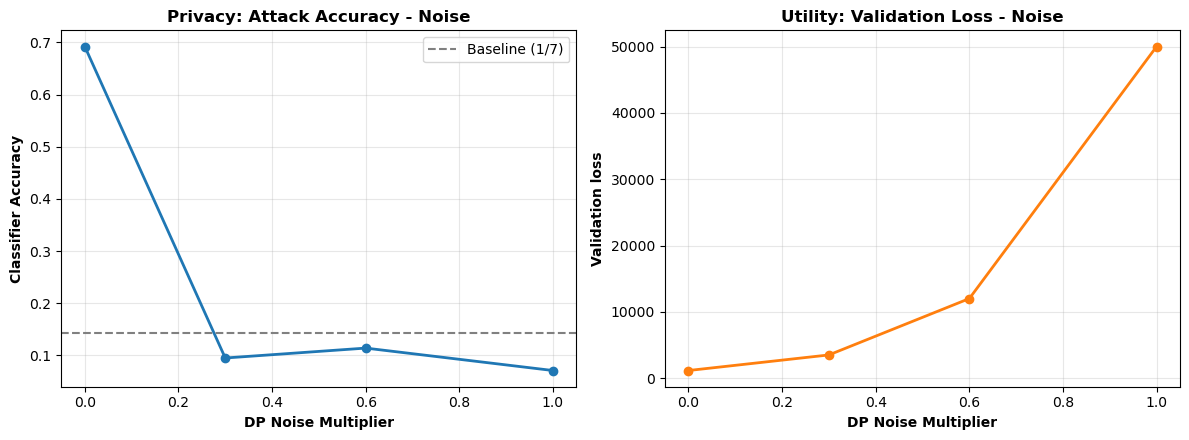

In [24]:
# Privacy-Utility trade-off analysis under untargeted and targeted Differential Privacy
# Evaluate how increasing noise multipliers impact both privacy (attack accuracy)
# and global model utility (validation loss)

# Noise levels tested during federated training
noise_levels = [0, 0.3, 0.6, 1.0]

# Results obtained with untargeted DP (noise applied to all weight tensors)
accuracy = [0.692, 0.095, 0.114, 0.071]  
val_loss = [1150, 3500, 12000, 50000]

# Results obtained with targeted DP (noise applied only to weight tensors 6, 18, 24)
# accuracy = [0.774, 0.333, 0.238, 0.262]  
# val_loss = [1150, 1150, 1175, 1175]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Privacy evaluation
# Show how attack accuracy changes as Differential Privacy noise increases
axes[0].plot(noise_levels, accuracy, marker = 'o', color = 'tab:blue', linewidth = 2)
axes[0].axhline(y=1/7, color = 'gray', linestyle = '--', label = 'Baseline (1/7)')
axes[0].set_xlabel('DP Noise Multiplier' , fontweight = "bold")
axes[0].set_ylabel('Classifier Accuracy', fontweight = "bold")
axes[0].set_title('Privacy: Attack Accuracy - Noise', fontweight = "bold")
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

# Plot 2: Utility evaluation
# Illustrate model utility at the same noise levels
axes[1].plot(noise_levels, val_loss, marker = 'o', color = 'tab:orange', linewidth = 2)
axes[1].set_xlabel('DP Noise Multiplier', fontweight = "bold")
axes[1].set_ylabel('Validation loss', fontweight = "bold")
axes[1].set_title('Utility: Validation Loss - Noise', fontweight = "bold")
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()